In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
file = '../data/outs/all_time.csv'

try:
    df = pd.read_csv(file, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo '{file}' não encontrado!")

Dados lidos com sucesso!


In [3]:
df.dtypes

nome      object
n          int64
m          int64
c          int64
fila      object
run        int64
l1         int64
l2         int64
llc        int64
cycles     int64
dtype: object

## Tempo de execução por quantidade de vértices

In [4]:
df_run_n = (
    df.groupby(['nome', 'fila'])['run']
      .agg(['mean', 'std', 'var'])
      .reset_index()
)
df_run_n

,nome,fila,mean,std,var
0,BAY,1LVBQ,81.3,1.567021,2.455556
1,BAY,2LVBQ,83.8,7.714345,59.511111
2,BAY,2LVBQDK,89.4,7.890923,62.266667
3,BAY,4LVBQ,116.2,3.224903,10.400000
4,BAY,BINH,108.0,1.247219,1.555556
5,BAY,KLVBQ,151.4,2.118700,4.488889
6,CAL,1LVBQ,563.0,27.455014,753.777778
7,CAL,2LVBQ,510.9,22.087955,487.877778
8,CAL,2LVBQDK,542.3,29.303204,858.677778
9,CAL,4LVBQ,741.5,93.919883,8820.944444


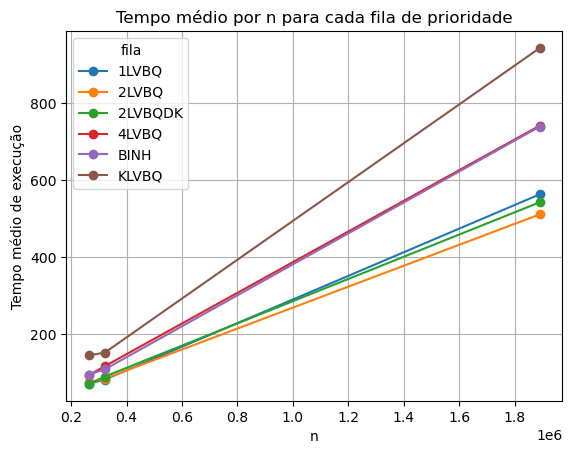

In [5]:
pivot = df.groupby(['n','fila'])['run'].mean().unstack()

pivot.plot(marker='o')
plt.xlabel('n')
plt.ylabel('Tempo médio de execução')
plt.title('Tempo médio por n para cada fila de prioridade')
plt.grid(True)
plt.savefig('run_n.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlação entre métricas e tempo de execução

In [6]:
df['l1_mr'] = df['l1'] / df['cycles']
df['l2_mr'] = df['l2'] / df['cycles']
df['llc_mr'] = df['llc'] / df['cycles']

In [7]:
df_run_miss = (
    df.groupby(['nome','fila'])[['run','l1','l2','llc','cycles', 'l1_mr', 'l2_mr', 'llc_mr']]
      .mean()
      .reset_index()
)
df_run_miss

,nome,fila,run,l1,l2,llc,cycles,l1_mr,l2_mr,llc_mr
0,BAY,1LVBQ,81.3,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,BAY,2LVBQ,83.8,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,BAY,2LVBQDK,89.4,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,BAY,4LVBQ,116.2,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,BAY,BINH,108.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
5,BAY,KLVBQ,151.4,0.0,0.0,0.0,0.0,NaN,NaN,NaN
6,CAL,1LVBQ,563.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
7,CAL,2LVBQ,510.9,0.0,0.0,0.0,0.0,NaN,NaN,NaN
8,CAL,2LVBQDK,542.3,0.0,0.0,0.0,0.0,NaN,NaN,NaN
9,CAL,4LVBQ,741.5,0.0,0.0,0.0,0.0,NaN,NaN,NaN
